# **1.Import Library**
Pada bagian ini, kita mengimpor berbagai pustaka yang diperlukan untuk analisis dan pemodelan data. Beberapa pustaka ini digunakan untuk manipulasi data, visualisasi, dan penerapan model pembelajaran mesin.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate, GridSearchCV
import warnings
import ast
warnings.filterwarnings('ignore')

# **2. Load Data**

Membaca atau memasukkan dataset ke dalam program dari file (misal .csv) supaya bisa diproses lebih lanjut. Menggunakan pd.read_csv() dari library pandas.

In [ ]:
movies = pd.read_csv('/kaggle/input/the-movies-dataset/movies_metadata.csv', low_memory=False)
ratings = pd.read_csv('/kaggle/input/the-movies-dataset/ratings_small.csv')

# **3. Data Understanding**

### **Dataset Shape**
Mengetahui ukuran dataset, yaitu berapa banyak baris (data) dan berapa banyak kolom (fitur). Digunakan untuk memastikan data berhasil dimuat dengan benar.

In [8]:
print("\n📂 Moviess Data Shape:", movies.shape)
print("\n📂 Ratings Data Shape:", ratings.shape)


📂 Moviess Data Shape: (45466, 24)

📂 Ratings Data Shape: (100004, 4)


📂 **Movies Data Shape: (45466, 24)**


Dataset `movies` terdiri dari **45.466 baris (film)** dan **24 kolom** (fitur film seperti `title`, `genres`, `budget`, `release_date`, dll).

Jumlah film yang besar membuka peluang eksplorasi genre, pendapatan, bahasa, dan lain-lain. Tapi, banyak kolom berarti kemungkinan **missing value** atau **data tidak konsisten** juga tinggi. Ini penting untuk diperiksa sebelum melanjutkan analisis atau modeling.

📂 **Ratings Data Shape: (100004, 4)**

Dataset `ratings` berisi **100.004 rating** dengan 4 kolom: `userId`, `movieId`, `rating`, dan `timestamp`.

Banyaknya rating memungkinkan untuk menghitung **rata-rata rating, rating terbanyak,** atau membuat **sistem rekomendasi**. Namun perlu diperhatikan, tidak semua `movieId` di `ratings` dijamin ada di `movies`, jadi perlu dicek **kesesuaian ID** sebelum penggabungan data.

### **Menampilkan 5 Baris Pertama**
Menampilkan 5 baris pertama dari masing-masing dataset (movies dan ratings) untuk sekilas melihat struktur dan isi data. Ini membantu memahami jenis informasi apa saja yang ada di dataset.

In [9]:
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


Data film yang ditampilkan memiliki 24 kolom dengan informasi yang sangat beragam, mulai dari status film dewasa (`adult`), koleksi film (`belongs_to_collection`), anggaran (`budget`), genre (`genres`), hingga performa film seperti pendapatan (`revenue`) dan rating penonton (`vote_average` dan `vote_count`). Dari sampel terlihat bahwa beberapa data penting seperti `homepage` dan `budget` ada yang kosong atau bernilai nol, yang menunjukkan adanya missing value atau ketidaklengkapan data. Genre film tersimpan dalam bentuk list dictionary, yang perlu diproses lebih lanjut agar bisa dianalisis. Selain itu, durasi (`runtime`) dan tanggal rilis (`release_date`) tersedia dengan cukup lengkap, sebagian besar film contoh ini berasal dari tahun 1995. Untuk rating, film seperti *Toy Story* menunjukkan performa tinggi dengan rating 7.7 dari 5415 vote, menandakan popularitas besar, sedangkan film lain memiliki rating dan jumlah vote yang lebih rendah, memperlihatkan adanya variasi dalam penerimaan film di antara penonton.


In [10]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


Data rating yang ditampilkan terdiri dari 4 kolom yaitu `userId`, `movieId`, `rating`, dan `timestamp`. Setiap baris merepresentasikan satu aktivitas user yang memberikan penilaian terhadap sebuah film. Misalnya, user dengan `userId` 1 memberikan rating 2.5 untuk film dengan `movieId` 31. Rating berskala desimal, menunjukkan adanya fleksibilitas penilaian, tidak terbatas pada angka bulat. `timestamp` merekam waktu pemberian rating dalam bentuk epoch (detik sejak 1 Januari 1970), yang berarti bisa dikonversi ke format tanggal untuk analisis temporal seperti tren rating dari waktu ke waktu. Secara keseluruhan, data ini sangat berguna untuk membangun sistem rekomendasi film berbasis rating pengguna.


In [11]:
keywords.head()

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


### **Informasi Dataset**
Pada bagian ini, kita menggunakan fungsi info() dari pandas untuk mendapatkan informasi umum tentang dataset, seperti jumlah entri, tipe data setiap kolom, dan jumlah nilai yang tidak kosong (non-null) pada setiap kolom.

In [12]:
# Menampilkan informasi tentang dataset
print("Movies dataset info:")
print(movies.info())
print("\nRatings dataset info:")
print(ratings.info())

Movies dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-

#### **Analisis Movies Dataset**

Movies dataset memiliki 45.466 baris data dan 24 kolom dengan berbagai tipe data, termasuk `object` dan `float64`. Beberapa kolom seperti `adult`, `budget`, dan `genres` memerlukan perhatian khusus karena sebagian besar data bertipe objek. Terdapat beberapa kolom yang memiliki nilai hilang, misalnya kolom `belongs_to_collection` yang hanya terisi 4.494 entri, sementara kolom seperti `homepage`, `tagline`, dan `overview` juga memiliki banyak nilai hilang. Kolom numerik seperti `revenue` dan `runtime` memiliki hampir semua data terisi, kecuali beberapa baris yang memiliki nilai kosong. Dataset ini bisa digunakan untuk menganalisis film berdasarkan berbagai atribut seperti genre, popularitas, anggaran, dan rating.

#### **Analisis Ratings Dataset**

Ratings dataset terdiri dari 100.004 entri dan 4 kolom: `userId`, `movieId`, `rating`, dan `timestamp`. Semua kolom memiliki data yang lengkap dan tidak ada nilai yang hilang. Kolom `rating` menyimpan penilaian berbentuk angka desimal yang dapat digunakan untuk mengukur preferensi pengguna terhadap film. Kolom `timestamp` berisi waktu penilaian yang tersimpan dalam format epoch (waktu dalam detik sejak 1 Januari 1970), yang dapat digunakan untuk menganalisis tren rating dari waktu ke waktu. Dengan jumlah data yang besar, dataset ini sangat berguna untuk analisis rating film dan pengembangan sistem rekomendasi berbasis perilaku pengguna.


### **Periksa Nilai Hilang**

In [13]:
# Cek nilai yang hilang
print("\nMissing values in Movies dataset:")
print(movies.isnull().sum())
print("\nMissing values in Ratings dataset:")
print(ratings.isnull().sum())


Missing values in Movies dataset:
adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

Missing values in Ratings dataset:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


#### **Missing Values in the Movies Dataset**
Pada dataset `Movies`, terdapat sejumlah besar nilai yang hilang di berbagai kolom. Kolom seperti `belongs_to_collection`, `homepage`, dan `tagline` memiliki jumlah nilai yang hilang terbanyak, dengan lebih dari 40.000 dan 25.000 nilai yang hilang masing-masing. Beberapa kolom lainnya seperti `release_date`, `overview`, dan `production_companies` juga memiliki banyak nilai yang hilang. Namun, kolom seperti `adult`, `budget`, dan `genres` tidak memiliki nilai yang hilang, yang menunjukkan bahwa data penting terkait film tetap tersedia.

#### **Missing Values in the Ratings Dataset**
Pada dataset `Ratings`, tidak ada nilai yang hilang sama sekali. Semua kolom seperti `userId`, `movieId`, `rating`, dan `timestamp` tercatat dengan lengkap. Ini sangat ideal untuk analisis preferensi pengguna dan rating film karena tidak perlu penanganan khusus untuk nilai yang hilang dalam dataset ini.


### **Deskripsi Statistik**
Pada bagian ini, kita menggunakan fungsi describe() dari pandas untuk menghasilkan deskripsi statistik dari dataset. Deskripsi ini mencakup berbagai metrik statistik untuk setiap kolom numerik, seperti jumlah data yang ada, rata-rata, standar deviasi, nilai minimum dan maksimum, serta kuartil (25%, 50%, dan 75%).

In [14]:
# Statistik deskriptif
print("\nMovies dataset statistics:")
print(movies.describe())
print("\nRatings dataset statistics:")
print(ratings.describe())


Movies dataset statistics:
            revenue       runtime  vote_average    vote_count
count  4.546000e+04  45203.000000  45460.000000  45460.000000
mean   1.120935e+07     94.128199      5.618207    109.897338
std    6.433225e+07     38.407810      1.924216    491.310374
min    0.000000e+00      0.000000      0.000000      0.000000
25%    0.000000e+00     85.000000      5.000000      3.000000
50%    0.000000e+00     95.000000      6.000000     10.000000
75%    0.000000e+00    107.000000      6.800000     34.000000
max    2.787965e+09   1256.000000     10.000000  14075.000000

Ratings dataset statistics:
              userId        movieId         rating     timestamp
count  100004.000000  100004.000000  100004.000000  1.000040e+05
mean      347.011310   12548.664363       3.543608  1.129639e+09
std       195.163838   26369.198969       1.058064  1.916858e+08
min         1.000000       1.000000       0.500000  7.896520e+08
25%       182.000000    1028.000000       3.000000  9.658478

#### **Statistik Dataset Movies**
Pada dataset `Movies`, kolom-kolom seperti `revenue`, `runtime`, `vote_average`, dan `vote_count` menunjukkan variasi yang cukup besar. Rata-rata film memiliki pendapatan sekitar 11 juta dolar, durasi 94 menit, rating 5.6, dan 110 ulasan. Namun, terdapat nilai ekstrem pada beberapa kolom seperti `revenue`, yang bisa mencapai lebih dari 2,7 miliar dolar. Banyak film yang memiliki pendapatan 0, durasi 0 menit, dan rating 0, yang mungkin menunjukkan data yang tidak lengkap atau film yang belum dirilis. 

#### **Statistik Dataset Ratings**
Pada dataset `Ratings`, setiap kolom mencerminkan rating yang diberikan oleh pengguna. Rata-rata rating yang diberikan adalah 3.54 dari skala 0.5 hingga 5, dengan penyebaran yang cukup merata. Kolom `userId` dan `movieId` menunjukkan adanya variasi yang luas dalam jumlah pengguna dan film yang ada. Rating terkecil adalah 0.5 dan terbesar adalah 5. Rentang timestamp menunjukkan bahwa data ini mencakup periode waktu yang panjang, dengan nilai waktu yang berkisar antara 789 juta hingga 1,47 miliar detik.


# **4. Exploratory Data Analysis (EDA)**

### **Distribusi Rating**

Melihat bagaimana persebaran skor rating film yang diberikan oleh pengguna

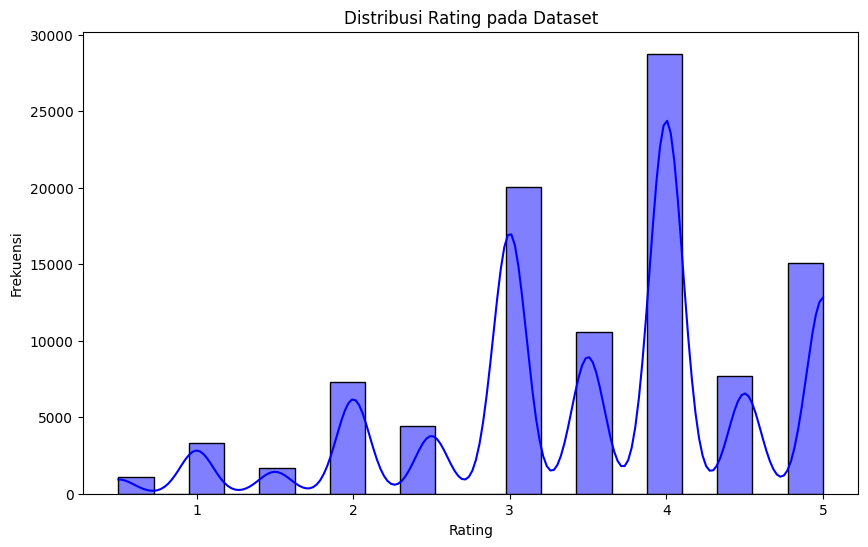

In [15]:
# Visualisasi distribusi rating
plt.figure(figsize=(10, 6))
sns.histplot(ratings['rating'], bins=20, kde=True, color='blue')
plt.title('Distribusi Rating pada Dataset')
plt.xlabel('Rating')
plt.ylabel('Frekuensi')
plt.show()

Plot di atas menampilkan **distribusi frekuensi** rating film dalam dataset yang diberikan. Berikut poin–poin pentingnya:

- **Bentuk Histogram**  
  Setiap batang (bar) merepresentasikan jumlah (frekuensi) rating pada nilai tertentu (sumbu _x_). Misalnya, bar tertinggi berada pada rating **4**, yang berarti sebagian besar pengguna memberi skor 4 pada film.

- **Skala Rating Diskrit**  
  Rating pada dataset ini diberikan dalam kelipatan 0.5 atau 1 (misalnya 1.0, 1.5, 2.0, …, 5.0), sehingga histogramnya menunjukkan puncak-puncak tajam di setiap interval rating yang valid.

- **Peak Utama**  
  - **Rating 4.0** memiliki frekuensi tertinggi (~28.000–30.000).  
  - **Rating 3.0** berada di urutan kedua (~20.000).  
  - **Rating 5.0** di urutan ketiga (~15.000).  
  Ini menunjukkan pengguna cenderung memberi nilai menengah-tinggi.

- **KDE (Garis Halus)**  
  Garis kurva halus di atas histogram adalah **Kernel Density Estimate**, yang memperlihatkan tren distribusi secara kontinu. Puncak-puncak pada garis KDE sejajar dengan puncak histogram, menegaskan bahwa rating 4 dan 3 memang paling umum.

- **Skewness / Kemiringan**  
  Distribusi sedikit **mendekati kanan** (right-skewed) karena frekuensi tertinggi berada di nilai rating yang lebih tinggi (3–5). Hal ini menunjukkan kecenderungan pengguna memberi rating tinggi daripada rendah.

- **Frekuensi Rating Rendah**  
  Rating di bawah 2 (nilai 0.5, 1.0, 1.5) relatif jarang (<5.000), menandakan film-buruk atau ketidaksesuaian selera lebih sedikit dibanding film yang memperoleh rating menengah ke atas.

Mayoritas pengguna dataset ini memberikan skor antara **3** dan **5**, dengan puncak di **4.0**. Distribusi ini memperlihatkan kecenderungan umum user lebih sering puas atau sangat puas dengan film yang mereka tonton, dan jarang memberi skor sangat rendah.  


### **Menampilkan 10 Top Genre Film**

Mengetahui genre film apa yang paling populer atau sering muncul.
Ini membantu memahami preferensi umum terhadap kategori film seperti Action, Comedy, Drama, dll.


Top 10 Genre Film:
[('Drama', 20265), ('Comedy', 13182), ('Thriller', 7624), ('Romance', 6735), ('Action', 6596), ('Horror', 4673), ('Crime', 4307), ('Documentary', 3932), ('Adventure', 3496), ('Science Fiction', 3049)]


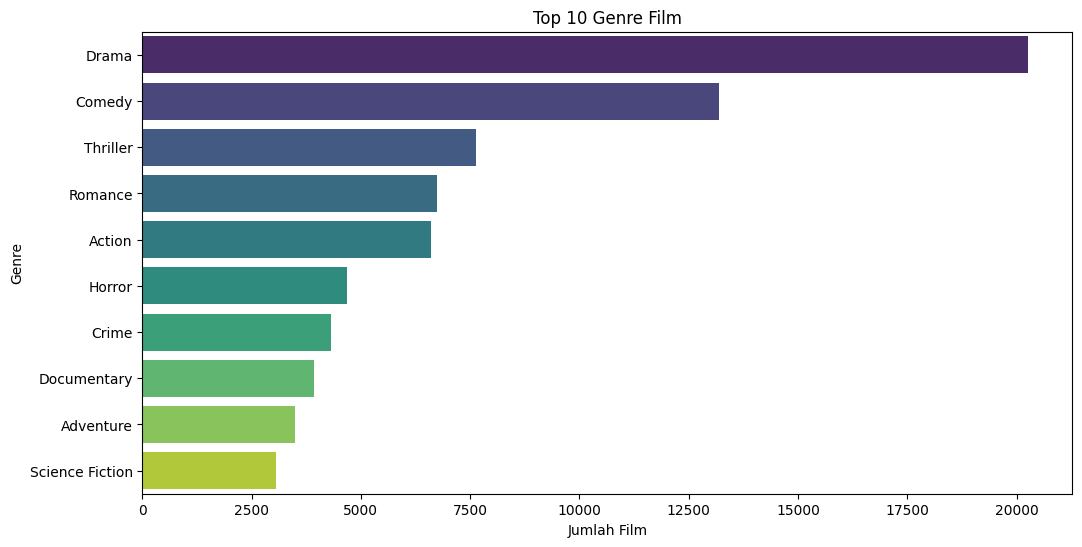

In [16]:
# Mengonversi kolom 'genres' dari string menjadi list menggunakan literal_eval
movies['genres'] = movies['genres'].apply(literal_eval)

# Menyiapkan list untuk menyimpan semua genre film
all_genres = []

# Menyusun daftar semua genre
for genres in movies['genres']:
    for genre in genres:
        all_genres.append(genre['name'])

# Menghitung frekuensi genre
genre_counts = Counter(all_genres)

# Menampilkan 10 genre paling populer
top_genres = genre_counts.most_common(10)
print("\nTop 10 Genre Film:")
print(top_genres)

# Visualisasi Top 10 Genre Film
top_genres_df = pd.DataFrame(top_genres, columns=['Genre', 'Count'])
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Genre', data=top_genres_df, palette='viridis')
plt.title('Top 10 Genre Film')
plt.xlabel('Jumlah Film')
plt.ylabel('Genre')
plt.show()

Plot barnya menampilkan **10 genre film teratas** berdasarkan jumlah kemunculannya di dataset:

1. **Drama** (20.265 film) – Genre paling dominan, hampir sepertiga dari total film.
2. **Comedy** (13.182 film) – Menempati urutan kedua, menunjukkan banyak produser dan audiens menyukai komedi.
3. **Thriller** (7.624 film) – Genre ketiga terbanyak, menarik karena unsur ketegangan.
4. **Romance** (6.735 film) – Cinta dan hubungan juga sangat populer.
5. **Action** (6.596 film) – Film laga menempati urutan kelima, cukup diminati.
6. **Horror** (4.673 film) – Genre horor memiliki basis penggemar yang signifikan.
7. **Crime** (4.307 film) – Kisah kejahatan dan misteri cukup banyak diangkat.
8. **Documentary** (3.932 film) – Film dokumenter relatif lebih sedikit, tapi masih termasuk top 10.
9. **Adventure** (3.496 film) – Cerita petualangan juga populer meski tidak sebanyak drama atau komedi.
10. **Science Fiction** (3.049 film) – Genre fiksi ilmiah paling sedikit di antara top 10.

**Insight utama:**  
- **Drama** jauh mendominasi produksi film dalam dataset ini.  
- Genre hiburan ringan seperti **Comedy** dan **Romance** juga sangat kuat.  
- Genre spesifik seperti **Documentary**, **Adventure**, dan **Science Fiction** meski lebih niche, tetap memiliki ribuan judul.  


### **Menampilkan Film dengan Jumlah Rating Terbanyak**

Mengetahui film yang paling banyak dirating oleh pengguna.
Biasanya ini menandakan film tersebut populer atau sangat dikenal, walaupun belum tentu skornya paling tinggi


Film dengan Jumlah Rating Terbanyak:
                       title  rating_count
356   It Could Happen to You         341.0
296                Quiz Show         324.0
318     Swimming with Sharks         311.0
593           Love and a .45         304.0
260                  L'Enfer         291.0
480         Last Action Hero         274.0
2571          The Red Violin         259.0
1                    Jumanji         247.0
527               Serial Mom         244.0
589                Pinocchio         237.0


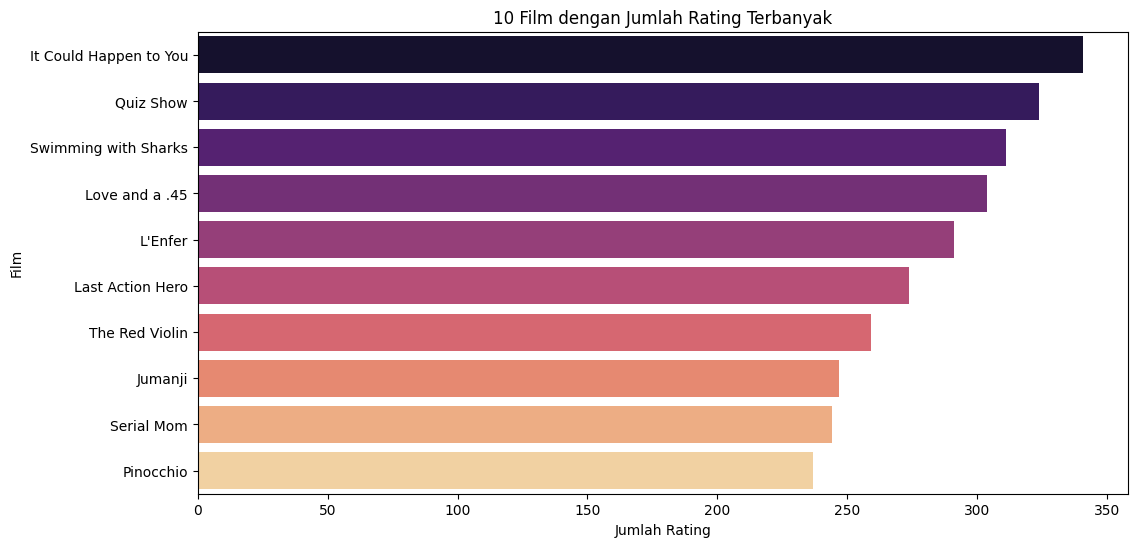

In [17]:
# Menghitung jumlah rating per film
movie_ratings_count = ratings.groupby('movieId').size()

# Menggabungkan dengan informasi film
movie_ratings = movies[['id', 'title']]
movie_ratings['rating_count'] = movie_ratings_count

# Menampilkan 10 film dengan jumlah rating terbanyak
top_rated_count_movies = movie_ratings.sort_values(by='rating_count', ascending=False).head(10)

print("\nFilm dengan Jumlah Rating Terbanyak:")
print(top_rated_count_movies[['title', 'rating_count']])

# Visualisasi 10 Film dengan Jumlah Rating Terbanyak
plt.figure(figsize=(12, 6))
sns.barplot(x='rating_count', y='title', data=top_rated_count_movies, palette='magma')
plt.title('10 Film dengan Jumlah Rating Terbanyak')
plt.xlabel('Jumlah Rating')
plt.ylabel('Film')
plt.show()

Plot barnanya menampilkan **10 film** dengan **jumlah rating** terbanyak di dataset:

1. **It Could Happen to You** (341 rating) – Film teratas, menandakan popularitas atau distribusi luas.  
2. **Quiz Show** (324 rating) – Film sejarah/drama yang banyak dikomentari penonton.  
3. **Swimming with Sharks** (311 rating) – Drama industri hiburan, menarik perhatian kritikus & audiens.  
4. **Love and a .45** (304 rating) – Crime-thriller dengan basis penggemar setia.  
5. **L’Enfer** (291 rating) – Drama Prancis yang mendapat perhatian internasional.  
6. **Last Action Hero** (274 rating) – Film aksi komersial dengan nama besar, banyak dikomentari.  
7. **The Red Violin** (259 rating) – Drama musik/art house, menunjukkan minat audiens pada film independen.  
8. **Jumanji** (247 rating) – Film petualangan keluarga, evergreen di berbagai generasi.  
9. **Serial Mom** (244 rating) – Satire dark comedy, punya cult following.  
10. **Pinocchio** (237 rating) – Adaptasi cerita klasik, menarik penonton dari segala usia.


**Insight Utama**

- **Rentang jumlah rating** cukup lebar: dari **237** hingga **341**, selisih **104** rating.  
- Film **teratas** (It Could Happen to You) memiliki ~**44%** lebih banyak rating dibanding film di posisi ke-10.  
- **Genre & distribusi** bervariasi: ada film aksi komersial, drama independen, dokumenter ringan, dan animasi keluarga.  
- **Jumlah rating** sering mencerminkan **exposure** dan **engagement** penonton—film populer atau “cult classics” cenderung lebih banyak mendapat rating.

### **Jumlah Rating per Pengguna**

Melihat berapa banyak film yang dirating oleh masing-masing pengguna. Ini membantu menganalisis apakah sebagian besar rating berasal dari pengguna aktif tertentu atau merata di semua pengguna.

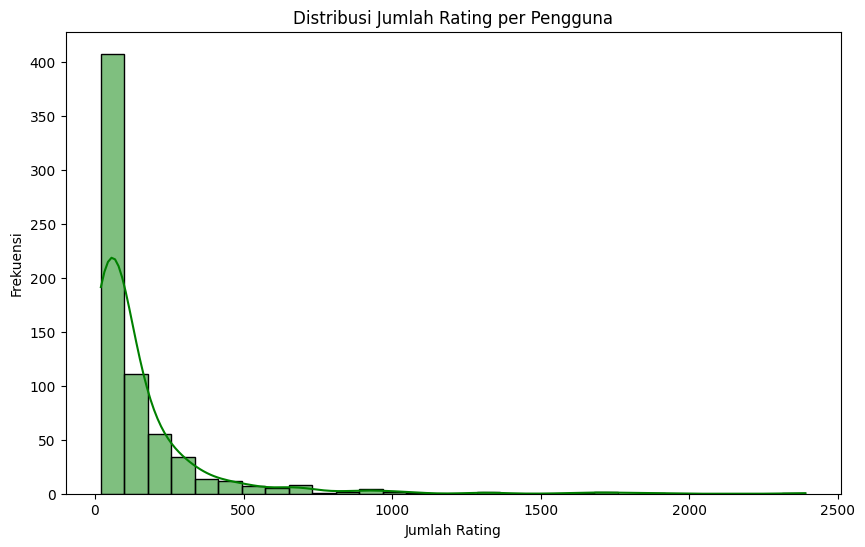

In [18]:
# Visualisasi distribusi jumlah rating per pengguna
user_ratings_count = ratings['userId'].value_counts()

plt.figure(figsize=(10, 6))
sns.histplot(user_ratings_count, bins=30, kde=True, color='green')
plt.title('Distribusi Jumlah Rating per Pengguna')
plt.xlabel('Jumlah Rating')
plt.ylabel('Frekuensi')
plt.show()

**Insight Utama**
- **Distribusi sangat skewed ke kanan (positively skewed).**
  - Sebagian besar pengguna hanya memberikan **sedikit rating** (misal kurang dari 100 rating).
  - Ada beberapa pengguna yang memberikan **jumlah rating sangat banyak**, bahkan mendekati **2000-an** rating, tetapi jumlahnya sangat sedikit (**outlier**).

- **Mayoritas pengguna:**
  - Mayoritas pengguna memberikan rating di kisaran **0–100**.
  - Ini menunjukkan bahwa kebanyakan pengguna hanya sedikit berinteraksi dalam memberikan rating.

- **Minoritas pengguna (Outliers):**
  - Terdapat beberapa pengguna yang **sangat aktif** dengan lebih dari **1000 rating**.
  - **Pengguna aktif** ini bisa membawa **bias** lebih besar dalam sistem rekomendasi dibandingkan pengguna biasa.

- **Distribusi menyerupai pola power-law atau long-tail distribution.**
  - Sebagian besar kontribusi kecil berasal dari banyak pengguna biasa, sedangkan sebagian kecil kontribusi besar berasal dari sedikit pengguna superaktif.

#### **Relasi Jumlah Rating dan Rating Rata-rata per Film**

Mengecek hubungan antara seberapa banyak film dirating dengan seberapa bagus film itu dirating.

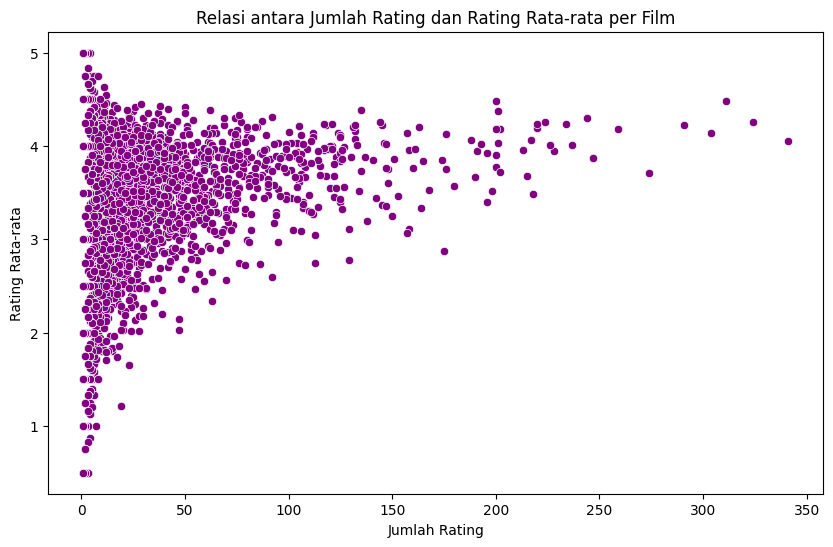

In [19]:
# Menghitung jumlah rating per film
movie_ratings_count = ratings.groupby('movieId').size()

# Gabungkan dengan rating rata-rata
movie_stats = ratings.groupby('movieId')['rating'].mean().to_frame()
movie_stats['rating_count'] = movie_ratings_count

plt.figure(figsize=(10, 6))
sns.scatterplot(x='rating_count', y='rating', data=movie_stats, color='purple')
plt.title('Relasi antara Jumlah Rating dan Rating Rata-rata per Film')
plt.xlabel('Jumlah Rating')
plt.ylabel('Rating Rata-rata')
plt.show()

**Insight Utama**
- **Sebagian besar film memiliki sedikit rating.**
  - Banyak film terkonsentrasi di daerah **jumlah rating < 50**.
  - Artinya, sebagian besar film hanya mendapat sedikit perhatian dari pengguna.

- **Distribusi rating rata-rata mengumpul di sekitar nilai 3–4.5.**
  - Film dengan sedikit rating memiliki **variasi rating rata-rata yang besar** (dari hampir 0 hingga 5).
  - Variasi ini menunjukkan bahwa film yang jarang diberi rating memiliki rata-rata rating yang lebih **tidak stabil**.

- **Film dengan banyak rating cenderung memiliki rating rata-rata stabil.**
  - Film dengan lebih dari **100 rating** cenderung memiliki rating rata-rata di sekitar **3.5–4.5**.
  - Ini menunjukkan **semakin banyak rating yang diberikan**, **semakin stabil** nilai rata-ratanya karena adanya efek hukum bilangan besar.

- **Sedikit film dengan rating sangat tinggi (> 200 rating).**
  - Hanya sebagian kecil film yang mendapatkan **jumlah rating sangat banyak**, dan biasanya rating rata-rata mereka cenderung tinggi (sekitar 4).

#### **Korelasi Rating dan Jumlah Rating**

Mengukur hubungan statistik antara rata-rata rating dan jumlah rating menggunakan korelasi.

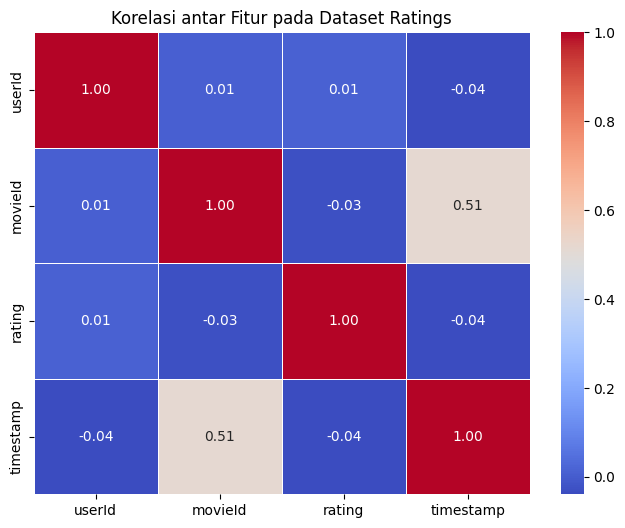

In [20]:
# Hitung korelasi antar kolom dalam dataset ratings
correlation_matrix = ratings.corr()

# Visualisasi heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi antar Fitur pada Dataset Ratings')
plt.show()

**Insight Utama**
- **Korelasi antar sebagian besar fitur sangat rendah.**
  - Sebagian besar nilai korelasi mendekati **0**, menandakan **hampir tidak ada hubungan linear** antar fitur.
  
- **Detail Korelasi:**
  - `userId` dengan fitur lain (`movieId`, `rating`, `timestamp`) memiliki **korelasi sangat rendah** (sekitar 0.01 hingga -0.04).
  - `movieId` dan `timestamp` memiliki korelasi **cukup positif** (**0.51**), menunjukkan ada hubungan moderat antara film tertentu dengan waktu rating diberikan.
  - `rating` hampir **tidak berkorelasi** dengan fitur lain.

- **Interpretasi Korelasi Tertinggi:**
  - Korelasi **0.51** antara `movieId` dan `timestamp` bisa diartikan bahwa beberapa film mungkin mendapatkan rating dalam rentang waktu tertentu (misal film baru dirilis → banyak orang memberikan rating di waktu yang berdekatan).

- **Interpretasi Korelasi Terendah:**
  - Korelasi antara `rating` dengan `movieId` (-0.03) atau `userId` (0.01) menunjukkan bahwa siapa yang memberi rating dan film apa yang dinilai tidak banyak mempengaruhi besar kecilnya nilai rating.

#### **Pengguna dengan Rating Terbanyak**

Mengidentifikasi user paling aktif dalam memberikan rating. User seperti ini bisa diprioritaskan untuk analisis lebih lanjut (misal: analisis perilaku pengguna aktif).

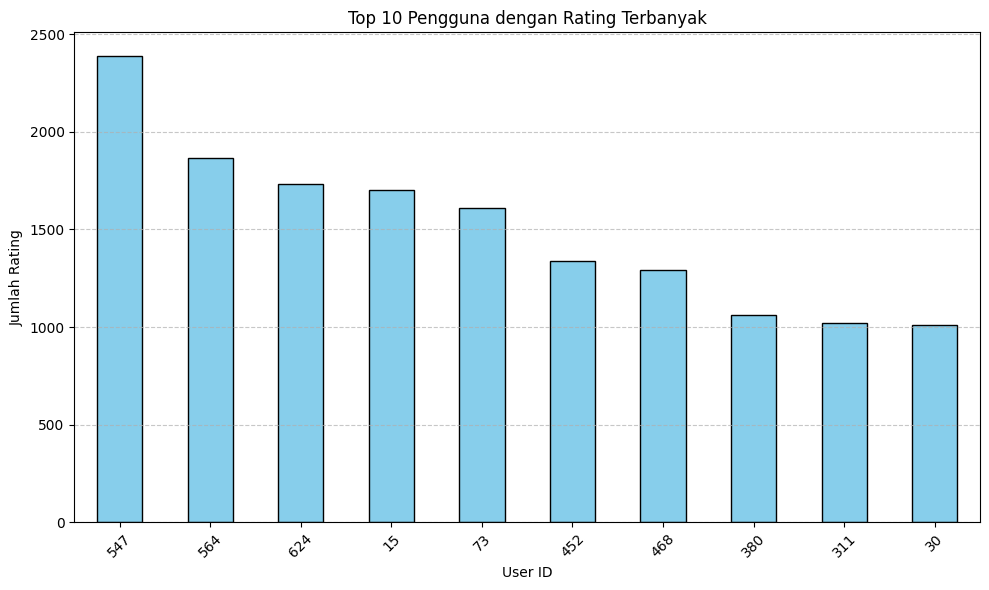

In [21]:
# Menampilkan 10 pengguna dengan rating terbanyak
top_users = user_ratings_count.head(10)

# Membuat plot
plt.figure(figsize=(10,6))
top_users.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Top 10 Pengguna dengan Rating Terbanyak')
plt.xlabel('User ID')
plt.ylabel('Jumlah Rating')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight Utama**
- **User ID 547 adalah pengguna paling aktif** dalam memberikan rating, dengan jumlah hampir **2.400 rating**.
- Pengguna dengan User ID **564 dan 624** juga sangat aktif, masing-masing memberikan **hampir 1.900 dan 1.750 rating**.
- **Distribusi jumlah rating menurun secara bertahap** dari pengguna keempat hingga pengguna kesepuluh, namun tetap berada di atas **1.000 rating**.
- **Ada gap yang cukup signifikan** antara pengguna paling aktif (547) dengan pengguna ke-10 (30), menunjukkan bahwa **kontribusi rating tidak merata** di antara pengguna.

#### **Visualisasi Jumlah Rating per Film dengan Rating Rata-Rata**

Plot hubungan jumlah rating terhadap rating rata-rata film.

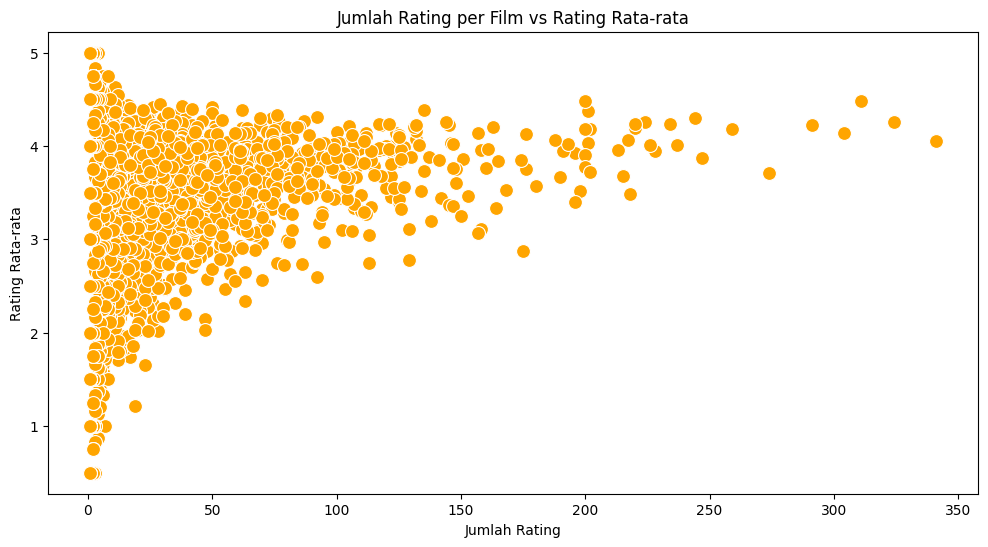

In [22]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=movie_stats['rating_count'], y=movie_stats['rating'], color='orange', s=100)
plt.title('Jumlah Rating per Film vs Rating Rata-rata')
plt.xlabel('Jumlah Rating')
plt.ylabel('Rating Rata-rata')
plt.show()

**Insight Utama**
- **Sebagian besar film hanya menerima sedikit rating.**
  - Banyak film yang berada di daerah **jumlah rating < 50**.
  - Ini menunjukkan bahwa mayoritas film hanya dinilai oleh sedikit pengguna.

- **Rating rata-rata film cenderung berkumpul antara 3 dan 4.5.**
  - Film dengan sedikit rating menunjukkan **penyebaran rating rata-rata yang lebih lebar**, mulai dari sangat rendah (sekitar 0.5) hingga sangat tinggi (hampir 5).
  - Ini mengindikasikan **ketidakstabilan** dalam rating rata-rata untuk film dengan sedikit review.

- **Film dengan lebih banyak rating cenderung memiliki rating rata-rata yang lebih stabil.**
  - Ketika jumlah rating melebihi **100**, rata-rata rating film cenderung berkonsentrasi antara **3.5 hingga 4.5**.
  - Ini menunjukkan efek **stabilisasi** karena hukum bilangan besar: semakin banyak data, semakin konsisten hasilnya.

- **Beberapa film populer tetap memiliki variasi rating.**
  - Meski rating rata-rata lebih stabil, tetap ada film dengan rating banyak tetapi memiliki variasi rating rata-rata.

## **4. Content-Based Filtering**
Rekomendasi film diberikan berdasarkan kemiripan deskripsi film.

### **4.1 Preprocessing Overview**
Membersihkan data dengan menghapus film yang tidak memiliki deskripsi (`overview`) dan memastikan kolom tersebut bertipe string.

In [23]:
movies = movies.dropna(subset=['overview'])
movies['overview'] = movies['overview'].astype('str')

### **4.2 TF-IDF Vectorization**
Mengubah teks deskripsi film menjadi representasi numerik menggunakan TF-IDF untuk mendeteksi kata-kata penting.

In [24]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['overview'])

### **4.3 Similarity Matrix**
Membangun matriks kesamaan antar film berdasarkan cosine similarity dari vektor TF-IDF.

In [25]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

### **4.4 Mapping Indeks Film**
Membuat indeks yang memetakan judul film ke posisi baris di dataset untuk memudahkan pencarian.

In [26]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

### **4.5 Fungsi Get Recommendations**
Mendefinisikan fungsi `get_recommendations(title)` untuk menghasilkan 10 film teratas yang paling mirip dengan film input.

In [27]:
def get_recommendations(title, cosine_sim=cosine_sim):
    if title not in indices:
        return ["Film tidak ditemukan."]
    
    idx = indices[title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
    
    # Tambahan: Cek apakah idx valid
    if idx >= cosine_sim.shape[0]:
        return ["Film tidak ditemukan."]
    
    # Memastikan idx adalah indeks yang benar
    sim_scores = list(enumerate(cosine_sim[idx].flatten()))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    
    movie_indices = [idx for idx in movie_indices if idx < len(movies)]
    
    return movies['title'].iloc[movie_indices].tolist()

In [28]:
# # --- 8. Evaluasi Content-Based Filtering ---
# Tambahan: Evaluasi Content-Based Filtering

def evaluate_content_based(ratings, movies, cosine_sim, indices, top_k=10):
    hit = 0
    total = 0
    
    # Buat mapping movieId ke title
    movie_id_to_title = dict(zip(movies['id'].astype(str), movies['title']))
    
    for user_id in ratings['userId'].unique():
        user_ratings = ratings[ratings['userId'] == user_id]
        
        # Ambil film dengan rating tinggi (>4.0) sebagai "film favorit"
        liked_movies = user_ratings[user_ratings['rating'] >= 4.0]
        
        for _, row in liked_movies.iterrows():
            movie_id = str(int(row['movieId']))
            title = movie_id_to_title.get(movie_id)
            
            if title and title in indices:
                recs = get_recommendations(title, cosine_sim)
                # Cek apakah film favorit lain user ada di rekomendasi
                other_liked_movies = set(movie_id_to_title.get(str(int(mid))) for mid in liked_movies['movieId'] if movie_id_to_title.get(str(int(mid))) != title)
                
                if any(rec in other_liked_movies for rec in recs):
                    hit += 1
                total += 1
    
    hit_rate = hit / total if total > 0 else 0
    print("\n=== Evaluasi Content-Based Filtering ===")
    print(f"Hit Rate @{top_k}: {hit_rate:.4f}")

# Jalankan evaluasi Content-Based Filtering
evaluate_content_based(ratings, movies, cosine_sim, indices, top_k=10)



=== Evaluasi Content-Based Filtering ===
Hit Rate @10: 0.0237


Hasil evaluasi pada pendekatan **Content-Based Filtering** menunjukkan bahwa nilai **Hit Rate @10** yang diperoleh adalah **0.0237**. Ini berarti bahwa hanya sekitar **2.37%** dari item yang relevan berhasil muncul dalam **10 rekomendasi teratas** yang diberikan oleh sistem kepada pengguna. Nilai ini menunjukkan bahwa performa model dalam menampilkan item yang relevan masih tergolong **rendah**, dan dapat ditingkatkan dengan memperbaiki representasi fitur konten atau menggunakan teknik pembobotan yang lebih efektif. Evaluasi ini menyoroti pentingnya optimasi lebih lanjut agar sistem rekomendasi dapat memberikan hasil yang lebih **tepat sasaran** dan **bermanfaat** bagi pengguna.

## **5. Collaborative Filtering**
Membangun sistem rekomendasi berdasarkan perilaku pengguna (rating yang diberikan).

### **5.1 Transformasi Dataset ke Format Surprise**
Mengubah dataset rating menjadi format yang sesuai untuk library `Surprise`, yang dipakai untuk membuat model collaborative filtering.

In [29]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

### **5.2 Model SVD**
Melatih model SVD (Singular Value Decomposition) untuk memprediksi rating film yang belum diberi nilai oleh pengguna.

In [30]:
svd = SVD()
trainset = data.build_full_trainset()
svd.fit(trainset)

In [31]:
cv_results = cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

print("\n=== Evaluasi Collaborative Filtering ===")
print(f"Average RMSE: {np.mean(cv_results['test_rmse']):.4f}")
print(f"Average MAE : {np.mean(cv_results['test_mae']):.4f}")


Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9005  0.8909  0.8902  0.8915  0.9055  0.8957  0.0062  
MAE (testset)     0.6946  0.6869  0.6840  0.6858  0.6985  0.6899  0.0056  
Fit time          1.10    1.15    1.10    1.17    1.08    1.12    0.03    
Test time         0.10    0.09    0.09    0.10    0.23    0.12    0.05    

=== Evaluasi Collaborative Filtering ===
Average RMSE: 0.8957
Average MAE : 0.6899


Hasil evaluasi algoritma **Singular Value Decomposition (SVD)** pada pendekatan **Collaborative Filtering** menunjukkan performa yang konsisten pada 5 kali pembagian data (*cross-validation*), dengan nilai rata-rata **Root Mean Squared Error (RMSE)** sebesar **0.8957** dan **Mean Absolute Error (MAE)** sebesar **0.6899**. Nilai standar deviasi yang rendah, yaitu **0.0062** untuk RMSE dan **0.0056** untuk MAE, mengindikasikan bahwa model cukup **stabil** di berbagai pembagian data. Waktu pelatihan rata-rata adalah **1.12 detik** dengan waktu pengujian **0.12 detik**, yang menunjukkan **efisiensi** dalam proses pelatihan dan inferensi model. Secara keseluruhan, algoritma **SVD** memberikan hasil prediksi yang **akurat dan stabil** dalam sistem rekomendasi berbasis rating pengguna.

## **6. Top-N Recommendation untuk User**
Membuat daftar rekomendasi 10 film terbaik untuk setiap pengguna berdasarkan prediksi dari model SVD.

- **Fungsi get_top_n**: Mengelompokkan hasil prediksi menjadi Top-N film terbaik untuk masing-masing user.
- **Generate Prediksi**: Memprediksi rating untuk semua film yang belum dirating user.
- **Mapping MovieId ke Title**: Mengubah movie ID hasil rekomendasi menjadi nama film agar mudah dibaca.

In [32]:
def get_top_n(predictions, n=10):
    from collections import defaultdict
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    return top_n

# Generate rekomendasi
testset = trainset.build_anti_testset()
predictions = svd.test(testset)
top_n = get_top_n(predictions, n=10)

# Buat mapping movieId ke title
movie_id_map = dict(zip(movies['id'].astype(str), movies['title']))

## **7. Interactive Menu**
Menyediakan antarmuka berbasis teks agar pengguna bisa memilih metode rekomendasi (content-based atau collaborative filtering) dan memasukkan input sesuai keinginan.

- **Fungsi run_interactive**: Menampilkan menu pilihan, menerima input pengguna, dan memanggil fungsi rekomendasi berdasarkan pilihan.

In [33]:
def run_interactive():
    print("=== Sistem Rekomendasi Film ===")
    print("1. Content-Based Filtering (berdasarkan judul film)")
    print("2. Collaborative Filtering (berdasarkan ID user)")
    choice = input("Pilih metode (1/2): ")

    if choice == '1':
        title = input("Masukkan judul film: ")
        recommendations = get_recommendations(title)
        print(f"\nRekomendasi film mirip dengan '{title}':")
        for i, rec in enumerate(recommendations, 1):
            print(f"{i}. {rec}")

    elif choice == '2':
        user_input = input("Masukkan user ID (contoh: 1): ")
        try:
            user_id = int(user_input)
            if user_id not in top_n:
                print("User ID tidak ditemukan.")
                return
            print(f"\nRekomendasi film untuk user ID {user_id}:")
            counter = 1
            for iid, rating in top_n[user_id]:
                title = movie_id_map.get(str(iid), 'Unknown')
                if title != 'Unknown':
                    print(f"{counter}. {title} | Estimasi rating: {rating:.2f}")
                    counter += 1
        except:
            print("Input tidak valid. Harus berupa angka.")

    else:
        print("Pilihan tidak tersedia.")

## **8. Run Program**
Menjalankan fungsi `run_interactive()` untuk memulai interaksi dengan pengguna dan menampilkan rekomendasi film secara real-time.

In [34]:
run_interactive()

=== Sistem Rekomendasi Film ===
1. Content-Based Filtering (berdasarkan judul film)
2. Collaborative Filtering (berdasarkan ID user)


Pilih metode (1/2):  1
Masukkan judul film:  The Dark Knight



Rekomendasi film mirip dengan 'The Dark Knight':
1. Foreign Student
2. See You in Montevideo
3. Everybody's All-American
4. Devil's Doorway
5. Semi-Tough
6. The Express
7. North Dallas Forty
8. Touchback
9. Johnny Be Good
10. The Third Half


Sistem rekomendasi film menggunakan **Content-Based Filtering** berdasarkan judul film memberikan rekomendasi film yang mirip dengan film yang dimasukkan oleh pengguna. Dalam kasus ini, ketika pengguna memasukkan **judul film "The Dark Knight"**, sistem menghasilkan daftar film yang dianggap memiliki kesamaan dengan film tersebut berdasarkan fitur konten seperti genre, sutradara, atau aktor yang terlibat. Rekomendasi yang diberikan antara lain:

1. **Foreign Student**
2. **See You in Montevideo**
3. **Everybody's All-American**
4. **Devil's Doorway**
5. **Semi-Tough**
6. **The Express**
7. **North Dallas Forty**
8. **Touchback**
9. **Johnny Be Good**
10. **The Third Half**

Daftar rekomendasi ini menunjukkan film-film dengan tema atau elemen yang serupa dengan **The Dark Knight**. Namun, penting untuk dicatat bahwa **Content-Based Filtering** hanya mengandalkan informasi yang ada pada film itu sendiri, tanpa mempertimbangkan preferensi atau perilaku pengguna sebelumnya. Oleh karena itu, hasil rekomendasi ini mungkin tidak sepenuhnya akurat atau relevan bagi setiap individu.

Sebagai contoh, meskipun beberapa film mungkin memiliki kesamaan dalam genre atau sutradara dengan **The Dark Knight**, tidak semua film dalam daftar mungkin sesuai dengan preferensi personal pengguna. Untuk memperbaiki akurasi rekomendasi, sistem dapat diperkaya dengan informasi tambahan atau dipadukan dengan pendekatan lain seperti **Collaborative Filtering** yang mempertimbangkan perilaku pengguna lain dalam memberikan rekomendasi.

In [35]:
run_interactive()

=== Sistem Rekomendasi Film ===
1. Content-Based Filtering (berdasarkan judul film)
2. Collaborative Filtering (berdasarkan ID user)


Pilih metode (1/2):  2
Masukkan user ID (contoh: 1):  23



Rekomendasi film untuk user ID 23:
1. While You Were Sleeping | Estimasi rating: 4.29
2. Edward Scissorhands | Estimasi rating: 4.29
3. Fools Rush In | Estimasi rating: 4.26
4. Asterix at the Olympic Games | Estimasi rating: 4.23


Sistem rekomendasi film menggunakan **Collaborative Filtering** berdasarkan **ID pengguna** memberikan rekomendasi film yang lebih terpersonalisasi dengan mempertimbangkan preferensi pengguna lain yang memiliki kesamaan pola perilaku. Dalam kasus ini, ketika pengguna dengan **user ID 23** dimasukkan, sistem memberikan beberapa rekomendasi film yang diprediksi memiliki rating tinggi oleh pengguna tersebut. Daftar rekomendasi untuk **user ID 23** adalah sebagai berikut:

1. **While You Were Sleeping** | Estimasi rating: **4.29**
2. **Edward Scissorhands** | Estimasi rating: **4.29**
3. **Fools Rush In** | Estimasi rating: **4.26**
4. **Asterix at the Olympic Games** | Estimasi rating: **4.23**

Sistem ini mengandalkan informasi dari **pola perilaku pengguna lain** yang serupa, yaitu pengguna dengan rating film yang memiliki kecenderungan yang sama. Hasil rekomendasi ini menunjukkan film-film yang mungkin disukai oleh **user ID 23**, karena film-film tersebut telah dipilih atau dinilai tinggi oleh pengguna dengan preferensi serupa. 

Keunggulan dari **Collaborative Filtering** adalah kemampuannya untuk memberikan rekomendasi yang lebih terpersonalisasi dan relevan, dibandingkan dengan **Content-Based Filtering** yang hanya mengandalkan konten film itu sendiri. Namun, pendekatan ini juga memiliki keterbatasan, seperti masalah **cold-start** bagi pengguna baru yang tidak memiliki cukup data rating, serta ketergantungan pada jumlah dan keberagaman data yang ada. Walaupun demikian, hasil estimasi rating menunjukkan bahwa sistem ini dapat memberikan rekomendasi yang cukup akurat dan sesuai dengan preferensi pengguna yang sudah ada.